In [16]:
# Generate the position coordinates of each joint for a specified end effector position (input x, y, z output joint angle and base rotation)

import numpy as np

# Need L1, L2, L3 for arm link lengths
# O1, O2, O3 for link angles
# 00 for base rotation

def generate_data(num_samples=10000, L1=1, L2=1, L3=1):
    angle_min, angle_max = -np.pi, np.pi

    t0 = np.random.uniform(angle_min, angle_max, num_samples)
    t1 = np.random.uniform(angle_min, angle_max, num_samples)
    t2 = np.random.uniform(angle_min, angle_max, num_samples)
    t3 = np.random.uniform(angle_min, angle_max, num_samples)

    angles = np.column_stack((t0, t1, t2, t3))

    # Absolute pitch angles
    theta1 = t1
    theta2 = t1 + t2
    theta3 = t1 + t2 + t3
     
     # Calculate current radius of end effector and z height
    r = L1*np.cos(theta1) + L2*np.cos(theta2) + L3*np.cos(theta3)
    z = L1*np.sin(theta1) + L2*np.sin(theta2) + L3*np.sin(theta3)
    
    # X and Y
    x = r*np.cos(t0)
    y = r*np.sin(t0)
    
    target_pos = np.column_stack((x, y, z))
    
    return target_pos, angles

X, y = generate_data(num_samples=100000)

In [12]:
X.shape

(100000, 3)

Matplotlib is building the font cache; this may take a moment.


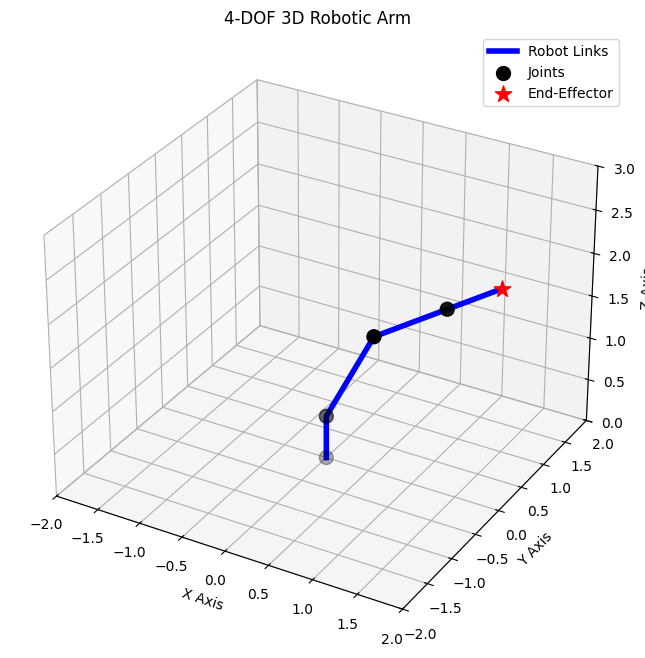

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def plot_4dof_arm(theta0, theta1, theta2, theta3):
    # 1. Define the physical robot (Link lengths in meters)
    L0 = 0.5  # Base height
    L1, L2, L3 = 1.0, 0.8, 0.6
    
    # 2. Calculate absolute pitch angles
    phi1 = theta1
    phi2 = theta1 + theta2
    phi3 = theta1 + theta2 + theta3
    
    # 3. Calculate coordinates for each joint
    # Joint 0: Origin (Base bottom)
    x0, y0, z0 = 0, 0, 0
    
    # Joint 1: Shoulder (Top of the rotating base)
    x1, y1, z1 = 0, 0, L0
    
    # Joint 2: Elbow
    r1 = L1 * np.cos(phi1)
    x2 = r1 * np.cos(theta0)
    y2 = r1 * np.sin(theta0)
    z2 = L0 + L1 * np.sin(phi1)
    
    # Joint 3: Wrist
    r2 = r1 + L2 * np.cos(phi2)
    x3 = r2 * np.cos(theta0)
    y3 = r2 * np.sin(theta0)
    z3 = z2 + L2 * np.sin(phi2)
    
    # End-Effector (The "Hand")
    r3 = r2 + L3 * np.cos(phi3)
    x4 = r3 * np.cos(theta0)
    y4 = r3 * np.sin(theta0)
    z4 = z3 + L3 * np.sin(phi3)
    
    # 4. Gather all points to plot lines
    xs = [x0, x1, x2, x3, x4]
    ys = [y0, y1, y2, y3, y4]
    zs = [z0, z1, z2, z3, z4]
    
    # 5. Set up Matplotlib 3D
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot the "bones" (lines connecting joints)
    ax.plot(xs, ys, zs, linewidth=4, color='blue', label='Robot Links')
    
    # Plot the "joints" (scatter points)
    ax.scatter(xs[:-1], ys[:-1], zs[:-1], color='black', s=100, label='Joints')
    
    # Plot the End-Effector distinctly
    ax.scatter(xs[-1], ys[-1], zs[-1], color='red', s=150, marker='*', label='End-Effector')
    
    # 6. Format the plot area to keep the aspect ratio square
    ax.set_xlim([-2, 2])
    ax.set_ylim([-2, 2])
    ax.set_zlim([0, 3])
    ax.set_xlabel('X Axis')
    ax.set_ylabel('Y Axis')
    ax.set_zlabel('Z Axis')
    ax.set_title('4-DOF 3D Robotic Arm')
    ax.legend()
    
    plt.show()

# Test the visualization with random angles!
# Base at 45 degrees, shoulder angled up, elbow bent down, wrist straight
plot_4dof_arm(
    theta0=np.pi/4,   # 45 degrees base rotation
    theta1=np.pi/3,   # 60 degrees shoulder pitch
    theta2=-np.pi/4,  # -45 degrees elbow pitch
    theta3=0.0        # 0 degrees wrist pitch
)

In [17]:
import torch

X, y = torch.from_numpy(X), torch.from_numpy(y)

device = "cuda" if torch.cuda.is_available() else "cpu"

X, y = X.to(device), y.to(device)